# Credit Card Fraud Detection - Decision Tree

This notebook documents Member 2's contribution to the project: implementing, evaluating, and analyzing a Decision Tree classifier for credit card fraud detection.

## Objective

The goal is to classify transactions as fraudulent (`Class = 1`) or non-fraudulent (`Class = 0`). Since fraud detection is a highly imbalanced classification problem, metrics such as precision, recall, F1-score, and ROC-AUC are more informative than accuracy alone.

A Decision Tree was selected because it:
- is simple to interpret and visualize,
- can capture non-linear relationships,
- works well for classification tasks,
- provides feature importance scores that help explain predictions.

## Step 1: Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Matplotlib is building the font cache; this may take a moment.


## Step 2: Load the prepared datasets

The preprocessing step was completed earlier in the project. The training data was balanced using SMOTE, while the test set was kept unchanged for fair evaluation.

In [2]:
X_train_resampled = pd.read_csv("X_train_resampled.csv")
y_train_resampled = pd.read_csv("y_train_resampled.csv").squeeze("columns")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

print("X_train_resampled shape:", X_train_resampled.shape)
print("X_test shape:", X_test.shape)
print("\nBalanced training labels:")
print(y_train_resampled.value_counts())
print("\nTest labels:")
print(y_test.value_counts())

X_train_resampled shape: (454902, 29)
X_test shape: (56962, 29)

Balanced training labels:
Class
0    227451
1    227451
Name: count, dtype: int64

Test labels:
Class
0    56864
1       98
Name: count, dtype: int64


## Step 3: Train the Decision Tree model

A fully unrestricted Decision Tree can easily overfit, especially after SMOTE balancing. To control complexity, a moderate depth and minimum split constraints are used.

In [3]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    criterion="gini",
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model.fit(X_train_resampled, y_train_resampled)

print(dt_model)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)


## Step 4: Make predictions

In [4]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_train = dt_model.predict(X_train_resampled)
y_prob_train = dt_model.predict_proba(X_train_resampled)[:, 1]

## Step 5: Evaluate the model

In fraud detection, recall is especially important because failing to detect a fraudulent transaction can be costly. Precision is also useful because too many false alarms reduce the practical value of the system.

In [5]:
test_results = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

results_df = pd.DataFrame(
    {
        "Metric": list(test_results.keys()),
        "Decision Tree": [round(value, 4) for value in test_results.values()]
    }
)

results_df

,Metric,Decision Tree
0,Accuracy,0.9765
1,Precision,0.0609
2,Recall,0.8776
3,F1 Score,0.1139
4,ROC-AUC,0.9474


In [6]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt, digits=4))

Confusion Matrix:

[[55538  1326]
 [   12    86]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9998    0.9767    0.9881     56864
           1     0.0609    0.8776    0.1139        98

    accuracy                         0.9765     56962
   macro avg     0.5303    0.9271    0.5510     56962
weighted avg     0.9982    0.9765    0.9866     56962



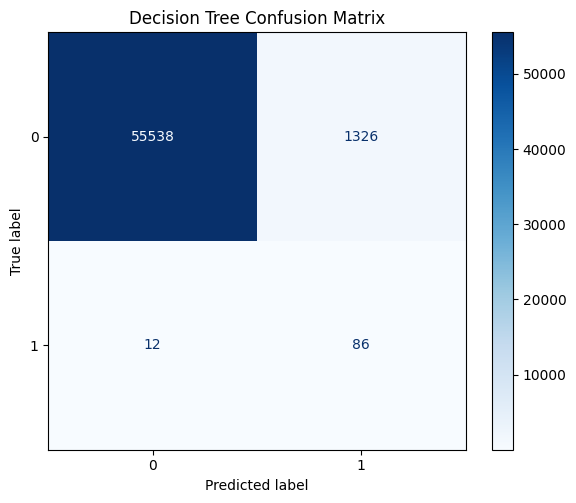

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap="Blues", ax=ax)
ax.set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

## Step 6: Check for overfitting

Decision Trees are prone to memorizing training patterns. Comparing train and test scores helps us judge whether the model generalizes well.

In [8]:
generalization_df = pd.DataFrame(
    {
        "Dataset": ["Training", "Testing"],
        "Accuracy": [
            round(accuracy_score(y_train_resampled, y_pred_train), 4),
            round(accuracy_score(y_test, y_pred_dt), 4)
        ],
        "ROC-AUC": [
            round(roc_auc_score(y_train_resampled, y_prob_train), 4),
            round(roc_auc_score(y_test, y_prob_dt), 4)
        ]
    }
)

generalization_df

,Dataset,Accuracy,ROC-AUC
0,Training,0.9805,0.9972
1,Testing,0.9765,0.9474


## Step 7: Inspect the most important features

Feature importance values help identify which anonymized variables had the biggest influence on the model's decisions.

In [9]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train_resampled.columns,
        "Importance": dt_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,V14,0.790153
1,V4,0.065420
2,V12,0.032744
3,V8,0.014499
4,V26,0.010867
5,V18,0.009388
6,V3,0.008767
7,V11,0.008079
8,V13,0.007572
9,V10,0.005963


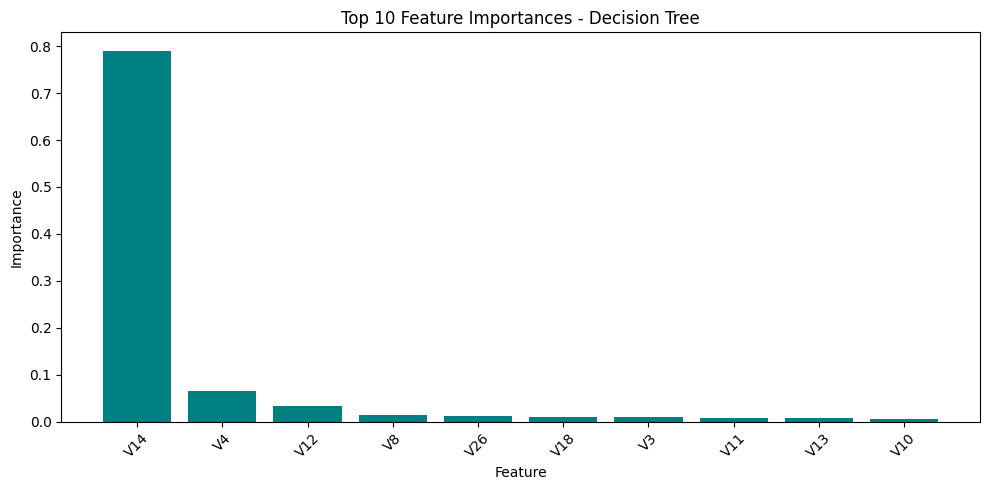

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"], color="teal")
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Visualize the upper levels of the tree

Displaying the first few levels makes the model easier to explain in the report and presentation while keeping the diagram readable.

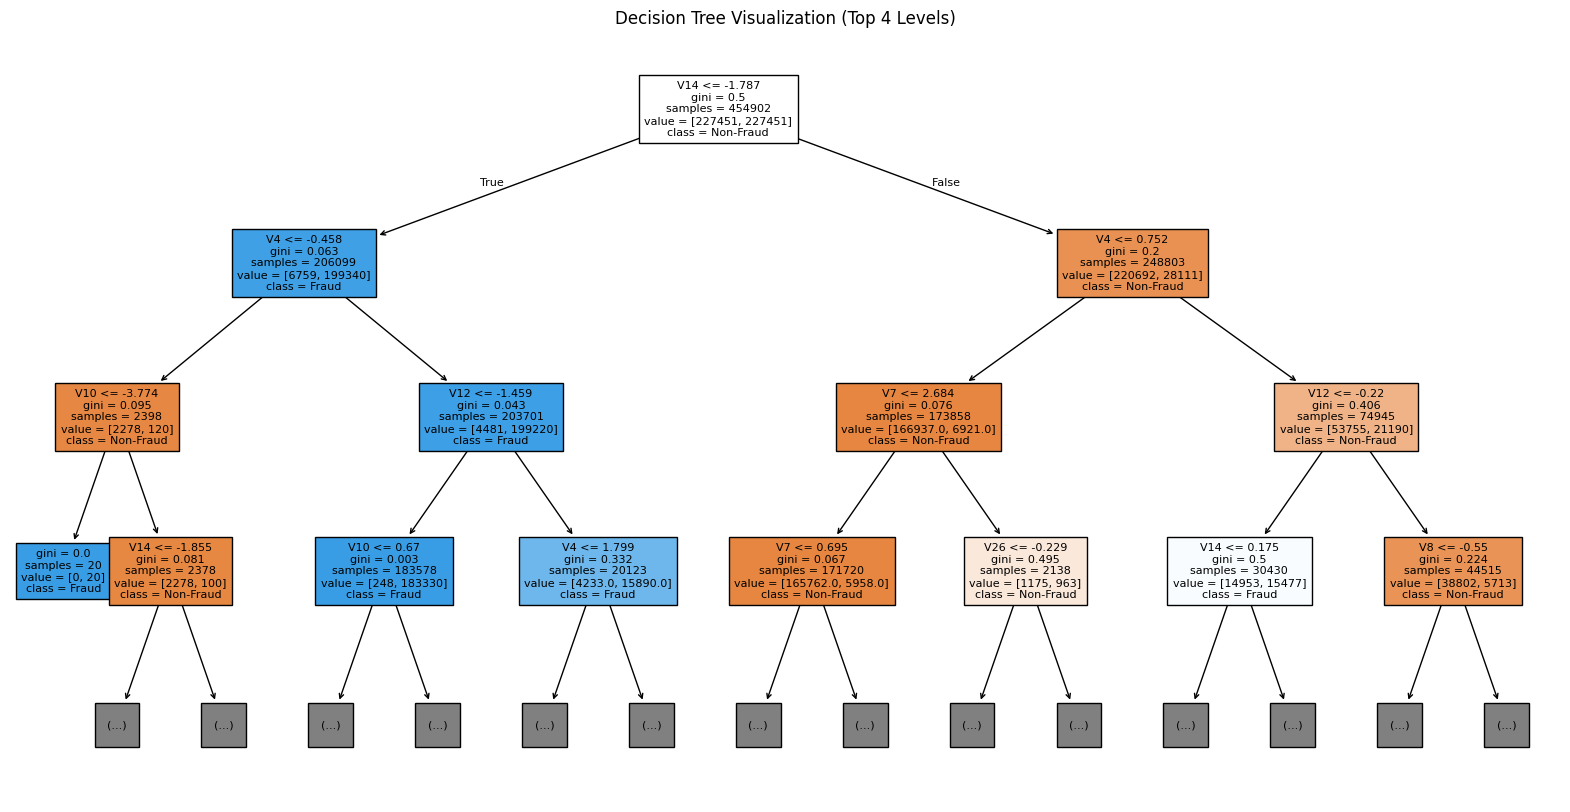

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X_train_resampled.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization (Top 4 Levels)")
plt.show()

## Step 9: Discussion

Strengths of the Decision Tree model:
- easy to understand and explain,
- can model non-linear decision boundaries,
- provides interpretable feature importance values.

Limitations:
- can still overfit if the tree grows too deep,
- performance can be sensitive to parameter settings,
- may be less stable than ensemble methods such as Random Forest.

Possible future improvements:
- tune hyperparameters using grid search,
- test pruning strategies,
- compare class weighting with SMOTE,
- compare the results directly with the other three models in the final notebook/report.

## Conclusion

The Decision Tree classifier provides an interpretable baseline for fraud detection and produces measurable performance on the credit card dataset. It is especially valuable for explaining decision paths, although its tendency to overfit means that parameter control and comparison with stronger ensemble models are important.